# Using breads to fit example linear and guassian data sets

### Import necessary modules from breads and packages

In [1]:
from breads.fit import fitfm
from breads.grid_search import grid_search
import numpy as np
import matplotlib.pyplot as plt

### First, we need to define the function for a line. Since the function for a line only contains linear parameters, no non-linear parameters are included. However, the `fitfm` function requires non-linear parameters, so we must include them in the definition of our line. 

The linear forward model function must return:

d: Data as a 1d vector with bad pixels removed (no nans)

M: Linear model as a matrix of shape (Nd,Np) with bad pixels removed (no nans). Nd is the size of the data vector and Np is the number of linear parameters.

s: Noise vector (standard deviation) as a 1d vector matching d.

See `breads.fm.template` for more information.

In [32]:
def linear_fm_func(nonlin_paras, dataobj, **fm_paras):
    x = dataobj["x"]
    y = dataobj["y"]
    s = dataobj["s"]

    M = np.vstack([x, np.ones_like(x)]).T

    # Return data, model, uncertainties
    return y, M, s

### Next, we need to define our example data set. 

In [33]:
dataobj = {
    "x": np.array([1, 2, 3, 4, 5]),
    "y": np.array([2.1, 3.5, 6.1, 9.2, 10.2]),
    "s": np.ones(5) * 0.1
}

### Finally, we need to use the `fitfm` function to return the best fit linear parameters.

In [34]:
results = fitfm(
    nonlin_paras=[], 
    dataobj=dataobj,
    fm_func=linear_fm_func,
    fm_paras={}
)

In [5]:
log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

In [6]:
print("Slope (m):", linparas[0], "±", linparas_err[0])
print("Intercept (b):", linparas[1], "±", linparas_err[1])
print("Reduced chi2:", rchi2)

Slope (m): 2.1899999999999995 ± 0.06920673381926946
Intercept (b): -0.3500000000000045 ± 0.22953276904451655
Reduced chi2: 22.93999999999998


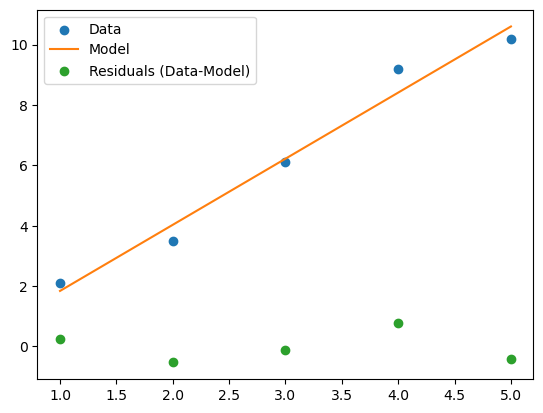

In [7]:
#model versus data
model=linparas[0]*dataobj["x"]+linparas[1]

plt.scatter(dataobj["x"], dataobj["y"], label='Data')
#add error bars
plt.plot(dataobj["x"], model, label='Model', linestyle='-', color='tab:orange')
plt.scatter(dataobj["x"], (dataobj["y"]-model), color='tab:green', label='Residuals (Data-Model)')
plt.legend()
plt.show()

### Now, we will define a a gaussian model with both linear and non-linear parameters. To keep it simple, we will fix sigma, or the standard deviation, so we only need to worry about one non-linear parameter. 

The gaussian function now has two parameters:

mu (mean): Non-linear

A (amplitude): Linear

In [29]:
def gaussian_mu_only_fm_func(nonlin_paras, dataobj, **fm_paras):
    """
    nonlin_paras = [mu]
    sigma is fixed
    """
    mu = nonlin_paras[0]
    sigma = fm_paras["sigma"]

    x = dataobj["x"]
    y = dataobj["y"]
    s = dataobj["s"]

    # Gaussian basis (linear in amplitude)
    A = np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    M = A[:, None]

    return y, M, s

### Next, we define the example gaussian data set.

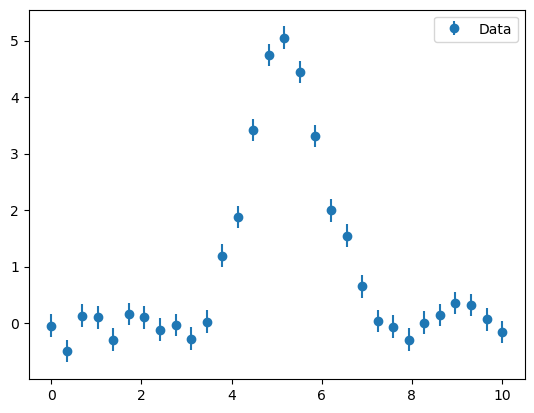

In [39]:
dataobj = {
    "x": np.linspace(0, 10, 30),
    "y": 5.0 * np.exp(-0.5 * ((np.linspace(0, 10, 30) - 5.2) / 0.8) ** 2)
         + np.random.normal(0, 0.2, 30),
    "s": np.ones(30) * 0.2,
}

plt.figure()
plt.errorbar(dataobj["x"], dataobj["y"], yerr=dataobj["s"],fmt='o', label='Data')
plt.legend()
plt.show()

### Finally, we will use the `grid_search` function of breads to find the best value of mu based on the probability of the model marginalized over the linear parameters and plot both our model and data.

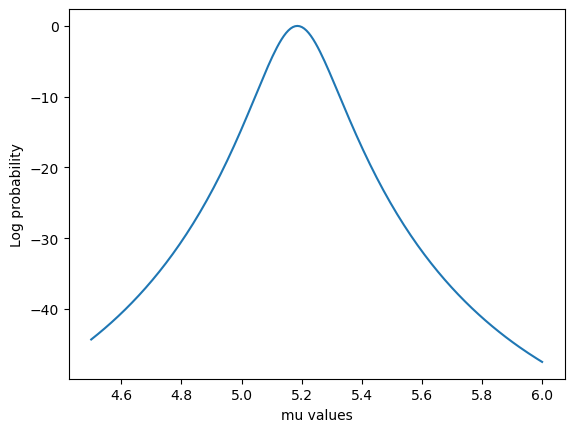

In [48]:
sigma_fixed=0.8
mu_grid = np.linspace(4.5, 6.0, 200)

log_prob, log_prob_H0, rchi2, linparas, linparas_err = grid_search(
    para_vecs=[mu_grid],
    dataobj=dataobj,
    fm_func=gaussian_mu_only_fm_func,
    fm_paras={"sigma": sigma_fixed},
    numthreads=None,
    bounds=None
)

plt.plot(mu_grid, log_prob)
plt.xlabel("mu values")
plt.ylabel("Log probability")
plt.show()

In [41]:
imax = np.nanargmax(log_prob)
mu_best = mu_grid[imax]

print("Best-fit mu:", mu_best)

Best-fit mu: 5.185929648241206


In [42]:
results = fitfm(
    nonlin_paras=[mu_best],
    dataobj=dataobj,
    fm_func=gaussian_mu_only_fm_func,
    fm_paras={"sigma": sigma_fixed}
)

In [43]:
log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

In [44]:
A = linparas[0]
A_err = linparas_err[0]

print("Amplitude A:", A, "±", A_err)
print("Reduced chi2:", rchi2)

Amplitude A: 4.96715269229023 ± 0.10625957505635589
Reduced chi2: 1.3473429646275017


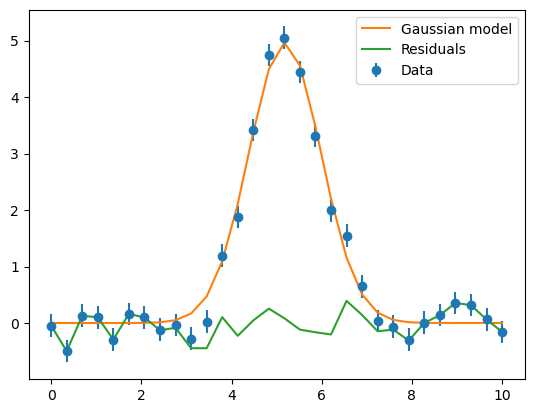

In [45]:
mu_fit, sigma_fit = mu_best, sigma_fixed

model = A * np.exp(-0.5 * ((dataobj["x"] - mu_fit) / sigma_fit) ** 2)

plt.figure()
plt.errorbar(dataobj["x"], dataobj["y"], yerr=dataobj["s"],fmt='o', label='Data')
plt.plot(dataobj["x"], model, color='tab:orange', label='Gaussian model')
plt.plot(dataobj["x"], dataobj["y"] - model, color='tab:green', label='Residuals')
plt.legend()
plt.show()